In [45]:
import zipfile
import io
import os
import numpy as np
import numpy.random as random
import scipy as sp
import pandas as pd
from prophet import Prophet
from pandas import Series, DataFrame

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
%matplotlib inline

# Display up to three decimal places
%precision 3

'%.3f'

# 1.1 Read the csv files

In [41]:
customers = pd.read_csv("../data/customers.csv")
geography = pd.read_csv("../data/geography.csv")
inventory = pd.read_csv("../data/inventory.csv")
order_items = pd.read_csv("../data/order_items.csv")
orders = pd.read_csv("../data/orders.csv")
payments = pd.read_csv("../data/payments.csv")
products = pd.read_csv("../data/products.csv")
promotions = pd.read_csv("../data/promotions.csv")
returns = pd.read_csv("../data/returns.csv")
reviews = pd.read_csv("../data/reviews.csv")
sales = pd.read_csv("../data/sales.csv")
shipments = pd.read_csv("../data/shipments.csv")
web_traffic = pd.read_csv("../data/web_traffic.csv")
sample = pd.read_csv("../data/sample_submission.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26572\2434114870.py:4: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/order_items.csv")


# 1.2 Check the shape of each DataFrame

In [43]:
dataframes = {
    'customers': customers,
    'geography': geography,
    'inventory': inventory,
    'order_items': order_items,
    'orders': orders,
    'payments': payments,
    'products': products,
    'promotions': promotions,
    'returns': returns,
    'reviews': reviews,
    'sales': sales,
    'shipments': shipments,
    'web_traffic': web_traffic,
    'sample': sample
}

for name, df in dataframes.items():
    rows, columns = df.shape
    print(f"The {name} table has {rows} rows and {columns} columns")

The customers table has 121930 rows and 7 columns
The geography table has 39948 rows and 4 columns
The inventory table has 60247 rows and 17 columns
The order_items table has 714669 rows and 7 columns
The orders table has 646945 rows and 8 columns
The payments table has 646945 rows and 4 columns
The products table has 2412 rows and 8 columns
The promotions table has 50 rows and 10 columns
The returns table has 39939 rows and 7 columns
The reviews table has 113551 rows and 7 columns
The sales table has 3833 rows and 3 columns
The shipments table has 566067 rows and 4 columns
The web_traffic table has 3652 rows and 7 columns
The sample table has 548 rows and 3 columns


# 1.3 Fill NaN Value

In [5]:
order_items = order_items.fillna("NO_PROMO", axis = 1).copy()
promotions = promotions.fillna("ALL", axis = 1).copy()

# 2.1 Sales, Orders and Customers' Behaviour Overtime

### The average orders per day is 170 orders. With the minimum and maximum numbers of orders are 8 orders and 803 days, respectively

In [6]:
# Get count as a DataFrame
orders_per_date = orders.groupby('order_date').size().reset_index(name='order_count')

# Sort by date
orders_per_date = orders_per_date.sort_values('order_date')

# Basic stats
print(f"Average orders per day: {orders_per_date['order_count'].mean():.2f}")
print(f"Max orders on a day: {orders_per_date['order_count'].max()}")
print(f"Min orders on a day: {orders_per_date['order_count'].min()}")

Average orders per day: 168.78
Max orders on a day: 803
Min orders on a day: 8


### The graph also follows a spike-like cycle, with spikes in orders happen in April every year. However, the trend of orders over time is decreasing. 

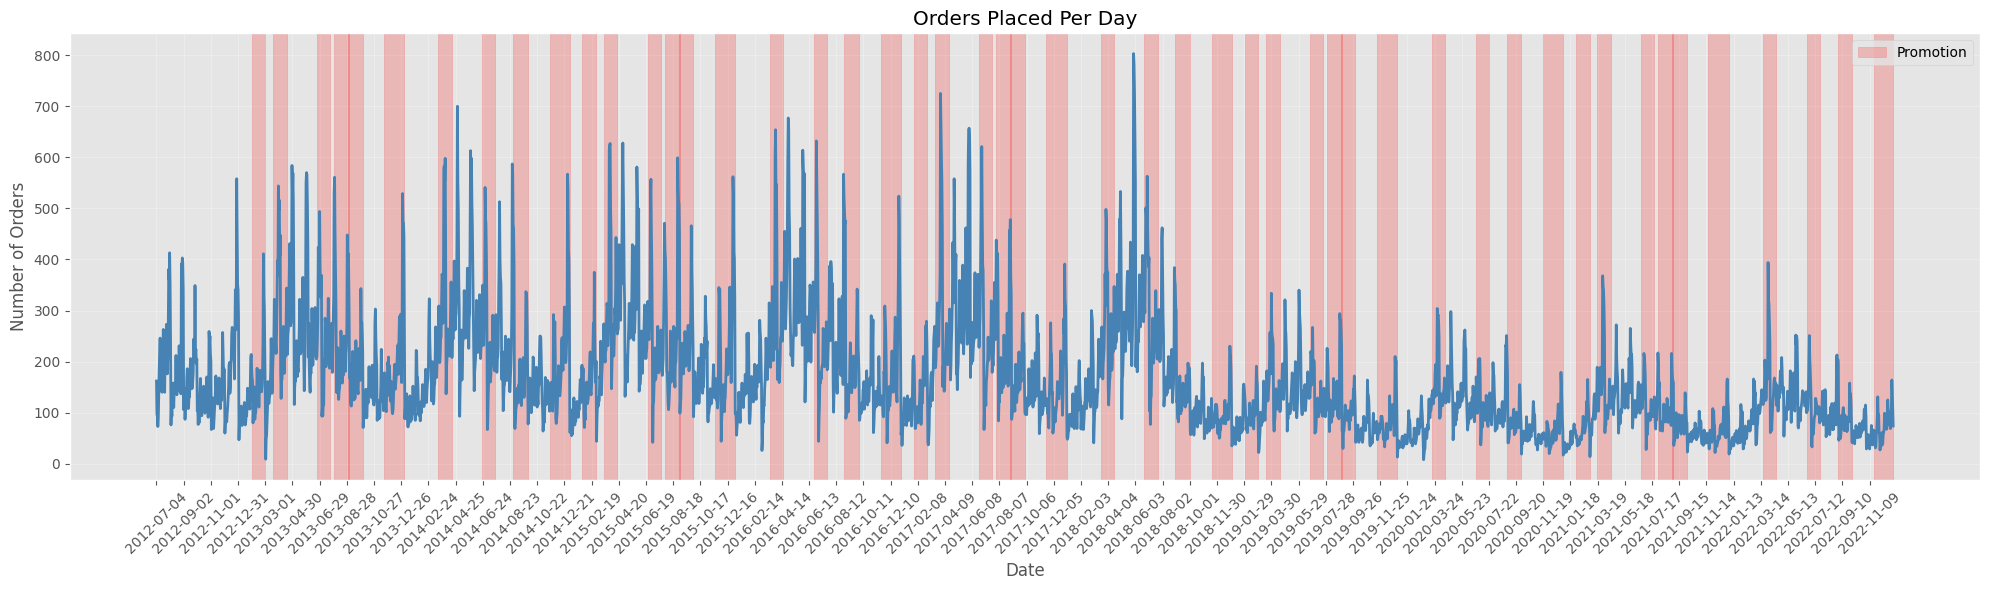

In [12]:
plt.figure(figsize=(20, 6))

# Ensure dates are datetime
orders_per_date['order_date'] = pd.to_datetime(orders_per_date['order_date'])
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

# Plot the main line
plt.plot(orders_per_date['order_date'], orders_per_date['order_count'], linewidth=2, color='steelblue')

# Add promotion durations as shaded regions
for idx, (_, promo) in enumerate(promotions.iterrows()):
    plt.axvspan(promo['start_date'], promo['end_date'], alpha=0.2, color='red', label='Promotion' if idx == 0 else '')

plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.title('Orders Placed Per Day')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

# Show every 60 days
step = 60
plt.xticks(orders_per_date['order_date'][::step], rotation=45)

plt.tight_layout()
plt.show()

### As a result, the revenue graph also follow a spike-like trend, with a similar downward trend over time.

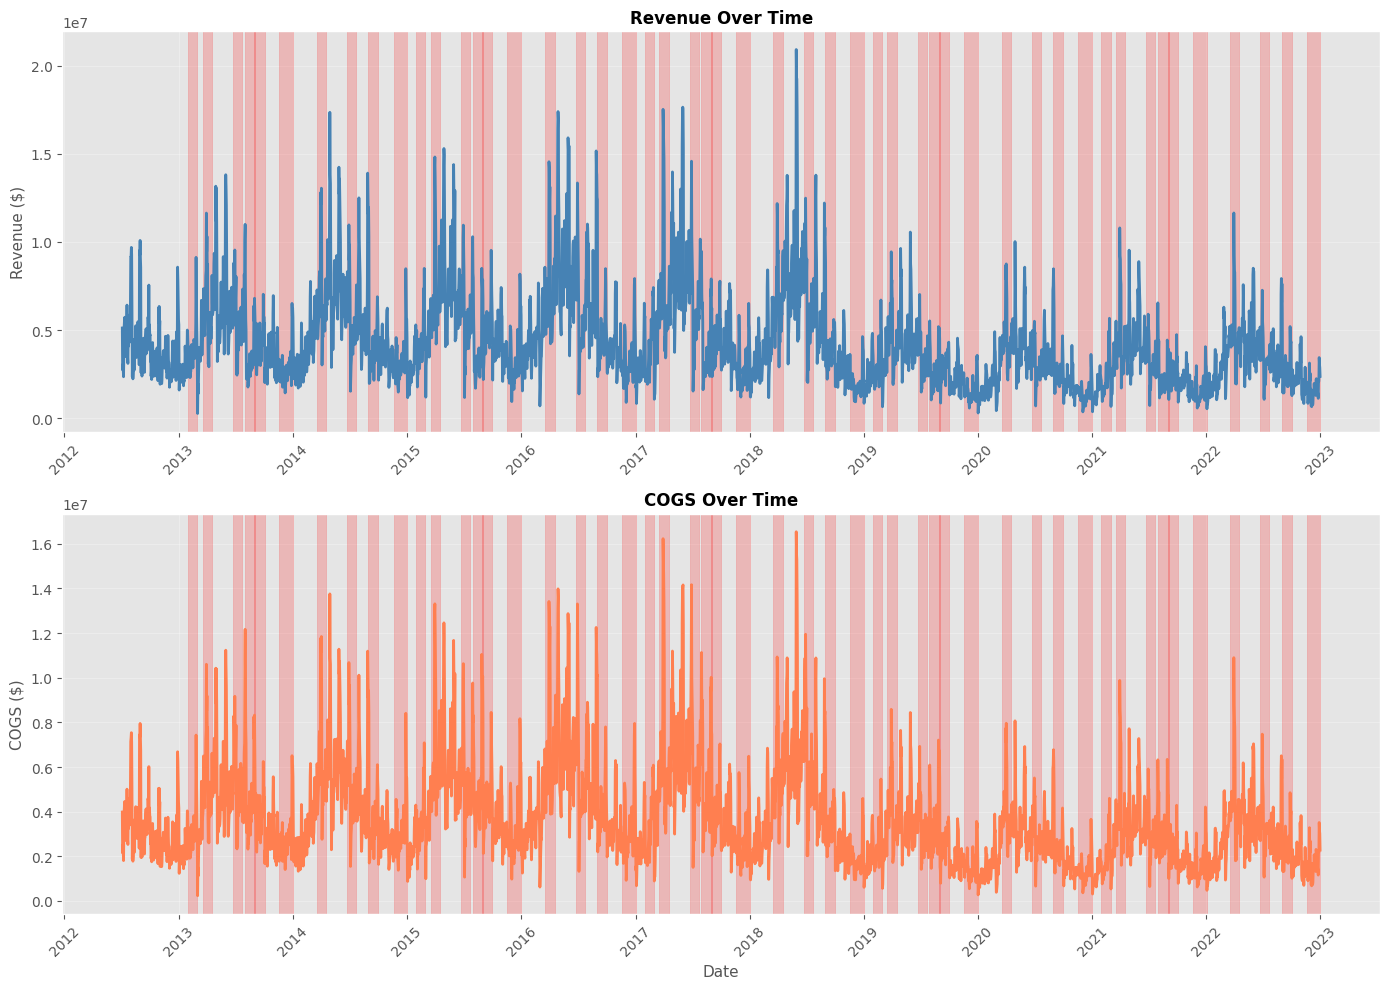

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Ensure Date is datetime
sales['Date'] = pd.to_datetime(sales['Date'])
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

# Revenue
axes[0].plot(sales['Date'], sales['Revenue'], linewidth=2, color='steelblue')
# Add promotion durations
for _, promo in promotions.iterrows():
    axes[0].axvspan(promo['start_date'], promo['end_date'], alpha=0.2, color='red')
axes[0].set_title('Revenue Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].tick_params(axis='x', rotation=45)

# COGS
axes[1].plot(sales['Date'], sales['COGS'], linewidth=2, color='coral')
# Add promotion durations
for _, promo in promotions.iterrows():
    axes[1].axvspan(promo['start_date'], promo['end_date'], alpha=0.2, color='red')
axes[1].set_title('COGS Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('COGS ($)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### The profit margin graph has interesting properities. It has a cycle of 2 years, which means it has similar profit margin behaviour every 2 year. And with every Blowout sale, the profit margin sharply drops. 

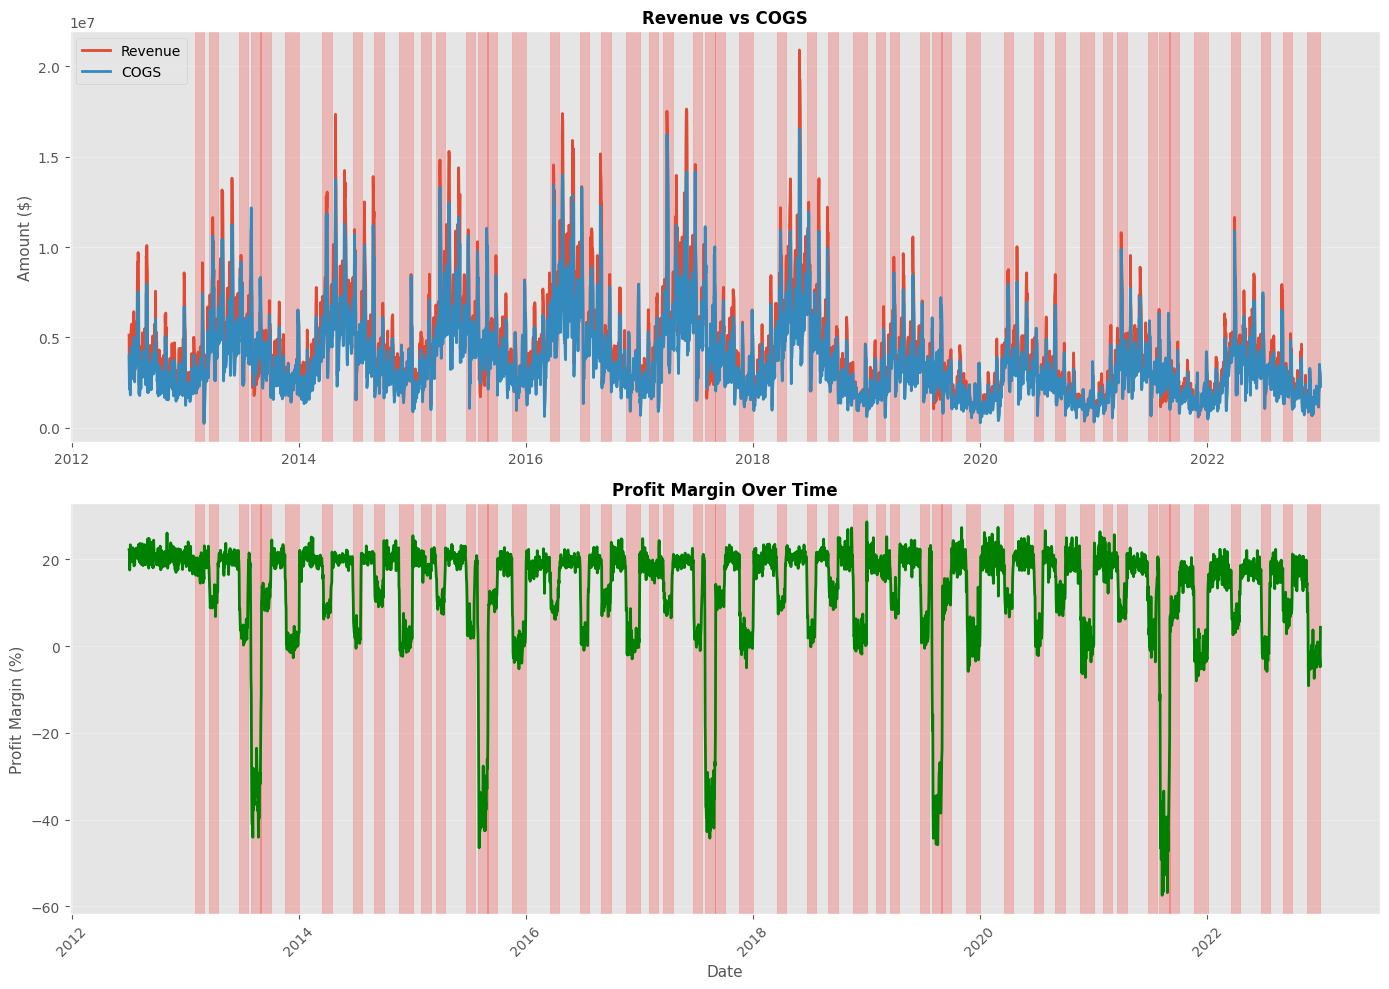

In [20]:
# Calculate profit
sales['Profit'] = sales['Revenue'] - sales['COGS']
sales['Profit_Margin'] = (sales['Profit'] / sales['Revenue'] * 100)
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Revenue and COGS
axes[0].plot(sales['Date'], sales['Revenue'], linewidth=2, label='Revenue')
axes[0].plot(sales['Date'], sales['COGS'], linewidth=2, label='COGS')
# Add promotion durations
for _, promo in promotions.iterrows():
    axes[0].axvspan(promo['start_date'], promo['end_date'], alpha=0.2, color='red')
axes[0].set_title('Revenue vs COGS', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amount ($)', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Profit Margin
axes[1].plot(sales['Date'], sales['Profit_Margin'], linewidth=2, color='green')
# Add promotion durations
for _, promo in promotions.iterrows():
    axes[1].axvspan(promo['start_date'], promo['end_date'], alpha=0.2, color='red')
axes[1].set_title('Profit Margin Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Profit Margin (%)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

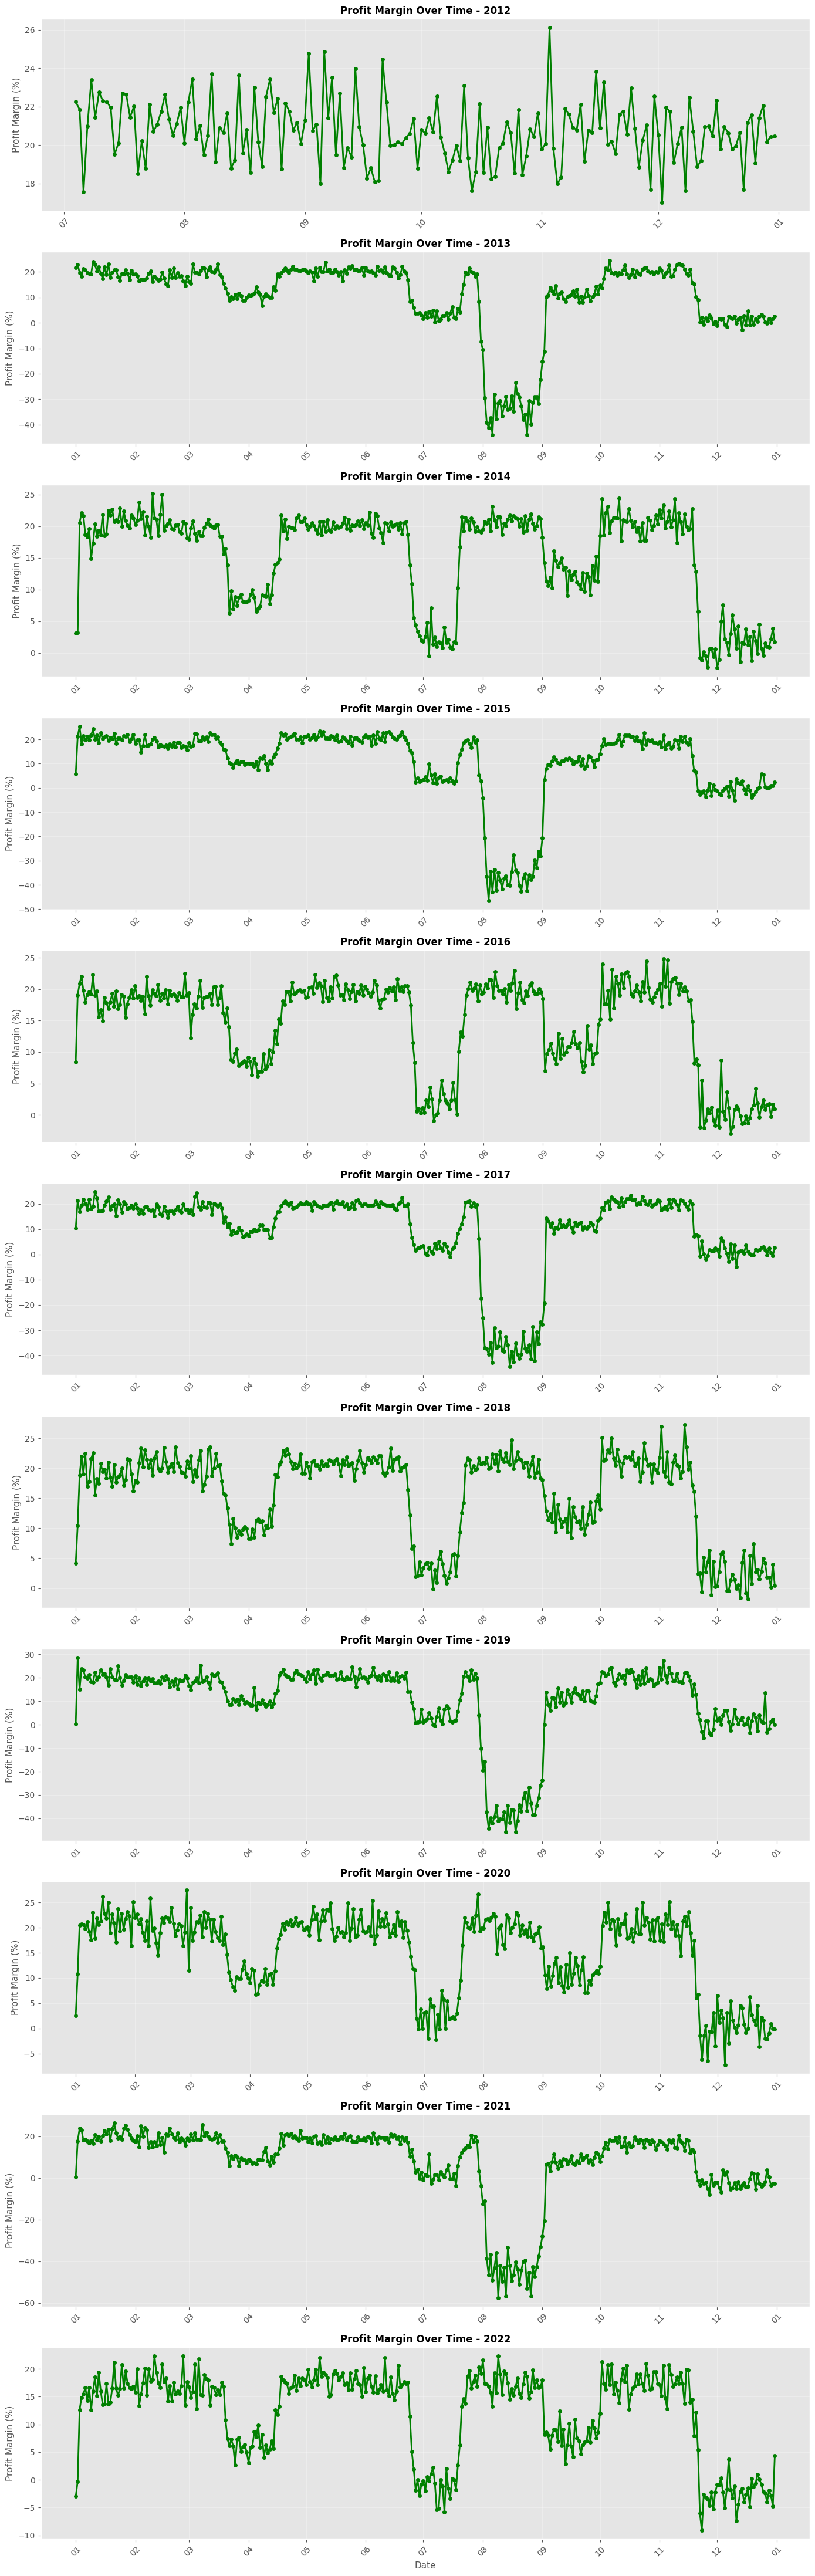

In [15]:
# Ensure Date is datetime
sales['Date'] = pd.to_datetime(sales['Date'])

# Extract year
sales['Year'] = sales['Date'].dt.year

# Get unique years and sort
years = sorted(sales['Year'].unique())

# Create subplots for each year
num_years = len(years)
fig, axes = plt.subplots(num_years, 1, figsize=(14, 4 * num_years))

# Handle case where there's only one year
if num_years == 1:
    axes = [axes]

# Plot each year
for idx, year in enumerate(years):
    year_data = sales[sales['Year'] == year]
    axes[idx].plot(year_data['Date'], year_data['Profit_Margin'], linewidth=2, color='green', marker='o', markersize=4)
    axes[idx].set_title(f'Profit Margin Over Time - {year}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Profit Margin (%)', fontsize=11)
    axes[idx].grid(True, alpha=0.3)
    
    # Format x-axis to show months
    axes[idx].xaxis.set_major_locator(mdates.MonthLocator())
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter('%m'))
    axes[idx].tick_params(axis='x', rotation=45)

# Set x-label only on the last subplot
axes[-1].set_xlabel('Date', fontsize=11)

plt.tight_layout()
plt.show()

### Next, I checked the unique visitors on the website over time. Despite the drop of orders and revenue, the number of visitors seems to increase, which is interesting.

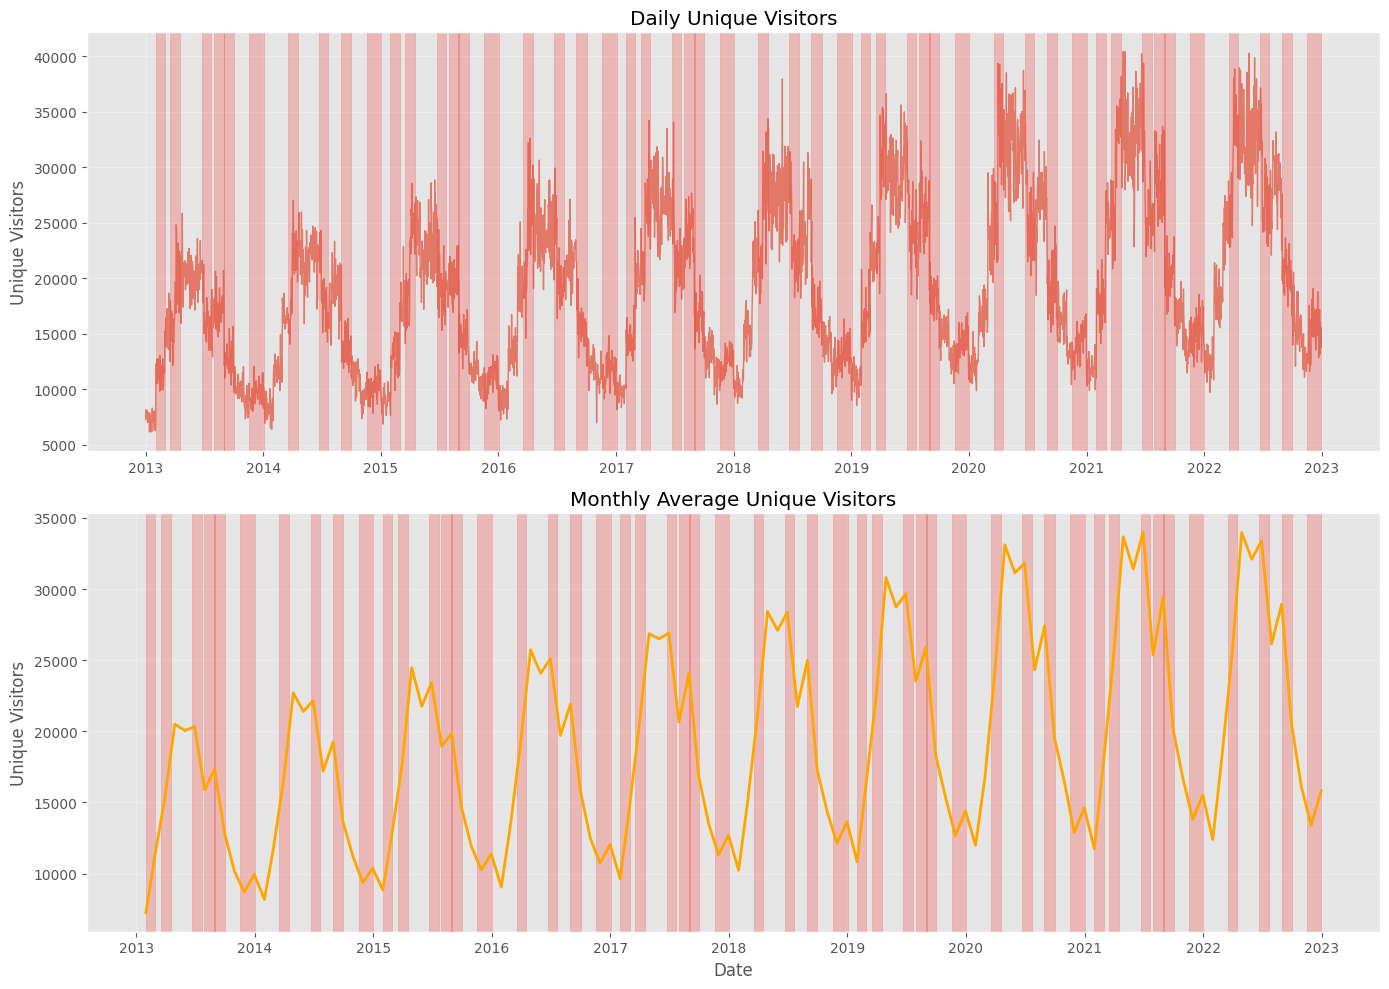

In [21]:
# Resample to monthly average
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
monthly_avg = web_traffic.set_index('date')['unique_visitors'].resample('ME').mean()
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily data
axes[0].plot(web_traffic['date'], web_traffic['unique_visitors'], linewidth=1, alpha=0.7, label='Daily')
# Add promotion durations
for _, promo in promotions.iterrows():
    axes[0].axvspan(promo['start_date'], promo['end_date'], alpha=0.2, color='red')
axes[0].set_title('Daily Unique Visitors')
axes[0].set_ylabel('Unique Visitors')
axes[0].grid(True, alpha=0.3)

# Monthly average
axes[1].plot(monthly_avg.index, monthly_avg.values, linewidth=2, color='orange', label='Monthly Avg')
# Add promotion durations
for _, promo in promotions.iterrows():
    axes[1].axvspan(promo['start_date'], promo['end_date'], alpha=0.2, color='red')
axes[1].set_title('Monthly Average Unique Visitors')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Unique Visitors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
orders['date'] = pd.to_datetime(orders['order_date'])
post_2013_orders = orders[orders['date'] >= pd.to_datetime("2013-01-01")].copy()
post_2013_orders = post_2013_orders.groupby('date').size().reset_index(name='order_count')
post_2013_orders['order_date_by_web_traffic'] = (post_2013_orders['order_count']/web_traffic['unique_visitors']*100)
post_2013_orders

,date,order_count,order_date_by_web_traffic
0,2013-01-01,288,3.970771
1,2013-01-02,47,0.576616
2,2013-01-03,81,1.086082
3,2013-01-04,83,1.029394
4,2013-01-05,78,0.989597
...,...,...,...
3647,2022-12-27,108,0.821293
3648,2022-12-28,164,1.026347
3649,2022-12-29,143,0.976776
3650,2022-12-30,106,0.772989


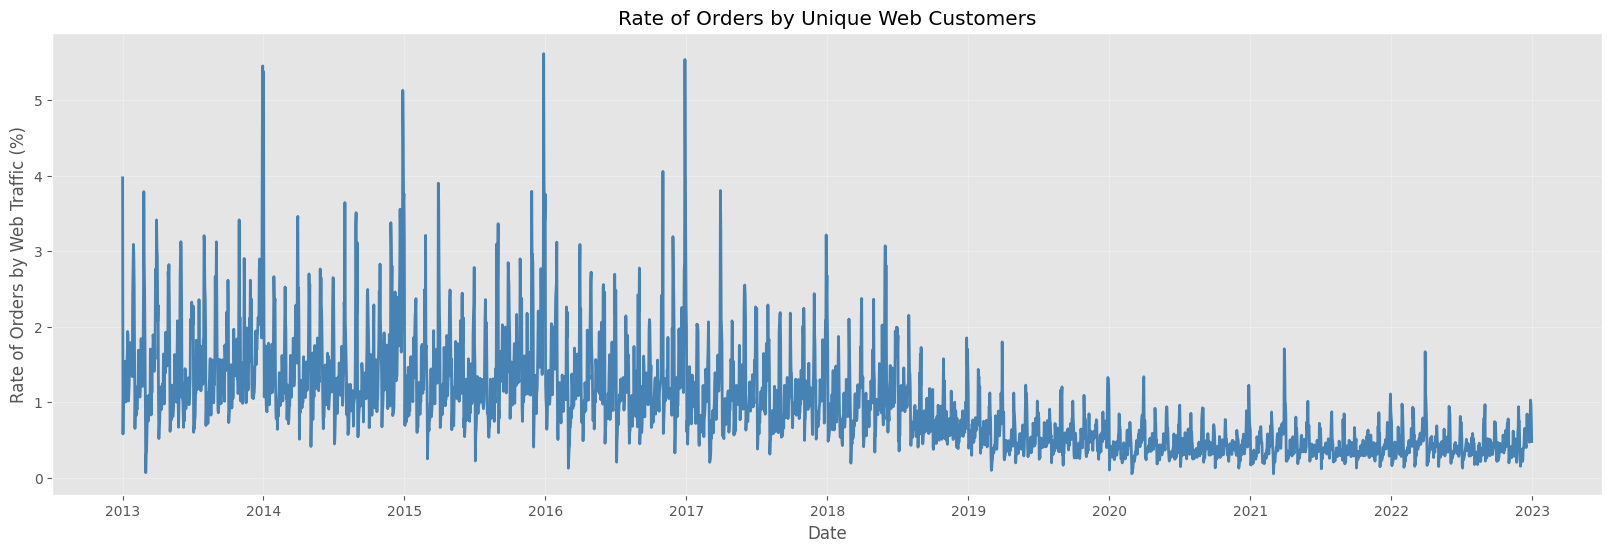

In [26]:
plt.figure(figsize=(20, 6))
plt.plot(post_2013_orders['date'], post_2013_orders['order_date_by_web_traffic'], linewidth=2, color='steelblue')
plt.xlabel('Date')
plt.ylabel('Rate of Orders by Web Traffic (%)')
plt.title('Rate of Orders by Unique Web Customers')
plt.grid(True, alpha=0.3)

In [30]:
promotions.head(50)

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,ALL,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,ALL,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,ALL,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,ALL,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000
5,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
6,PROMO-0007,Spring Sale 2014,percentage,12.0,2014-03-18,2014-04-17,ALL,email,1,0
7,PROMO-0008,Mid-Year Sale 2014,percentage,18.0,2014-06-23,2014-07-22,ALL,social_media,0,0
8,PROMO-0009,Fall Launch 2014,percentage,10.0,2014-08-30,2014-10-01,ALL,all_channels,0,100000
9,PROMO-0010,Year-End Sale 2014,percentage,20.0,2014-11-19,2015-01-02,ALL,all_channels,0,100000


### Next is the rating reviews from time to time. As we can see, the overall ratings stay unchanged at 3.9.

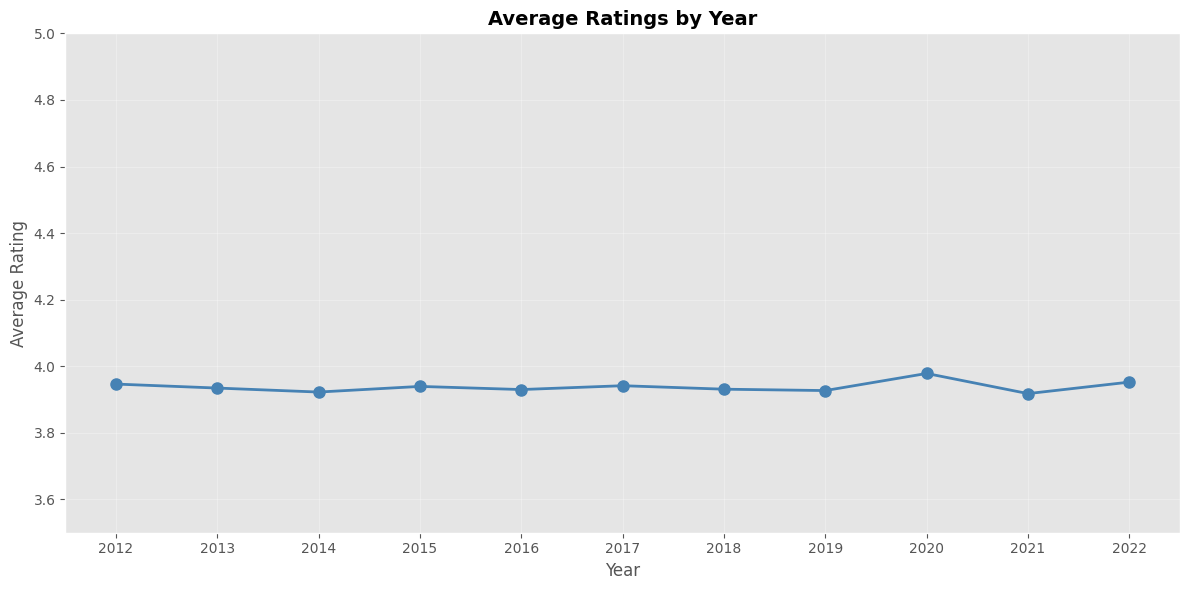

In [38]:
# Convert review_date to datetime
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

# Extract year from review_date
reviews['year'] = reviews['review_date'].dt.year

# Calculate average rating per year
avg_rating_by_year = reviews.groupby('year')['rating'].mean()

# Create the graph
plt.figure(figsize=(12, 6))
plt.plot(avg_rating_by_year.index, avg_rating_by_year.values, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.title('Average Ratings by Year', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(avg_rating_by_year.index)
plt.ylim(3.5, 5.0)

plt.tight_layout()
plt.show()

# 3.1 ML Modeling

In [ ]:
# 1. Load Data (Sử dụng đường dẫn tương đối) [cite: 267, 345, 381]
train_df = pd.read_csv('../data/sales.csv', parse_dates=['Date'])

# 2. Tiền xử lý dữ liệu (Prophet yêu cầu 2 cột: ds và y) [cite: 12]
# Chuẩn bị DataFrame riêng cho Revenue và COGS [cite: 86]
df_revenue = train_df[['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})
df_cogs = train_df[['Date', 'COGS']].rename(columns={'Date': 'ds', 'COGS': 'y'})

# 3. Huấn luyện mô hình cho Revenue
# Sử dụng toàn bộ dữ liệu từ 2012-2022 để dự báo tương lai
model_rev = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model_rev.fit(df_revenue)

# 4. Huấn luyện mô hình cho COGS (Dự báo độc lập)
model_cogs = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model_cogs.fit(df_cogs)

# 5. Tạo khung thời gian dự báo tương lai (2023-01-01 -> 2024-07-01)
future_dates = pd.date_range(start='2023-01-01', end='2024-07-01', freq='D')
future_df = pd.DataFrame({'ds': future_dates})

# 6. Tiến hành dự báo cho cả hai cột 
forecast_rev = model_rev.predict(future_df)
forecast_cogs = model_cogs.predict(future_df)

submission = pd.DataFrame({
    'Date': forecast_rev['ds'].dt.strftime('%Y-%m-%d'),
    'Revenue': forecast_rev['yhat'].clip(lower=0).round(2), 
    'COGS': forecast_cogs['yhat'].clip(lower=0).round(2)
})


submission['COGS'] = submission.apply(lambda x: min(x['COGS'], x['Revenue'] * 0.9), axis=1)

submission.to_csv('../data/submission.csv', index=False)
print("Đã tạo file submission thành công cho cả Revenue và COGS!")

22:25:25 - cmdstanpy - INFO - Chain [1] start processing
22:25:26 - cmdstanpy - INFO - Chain [1] done processing
22:25:27 - cmdstanpy - INFO - Chain [1] start processing
22:25:28 - cmdstanpy - INFO - Chain [1] done processing


Đã tạo file submission thành công cho cả Revenue và COGS!


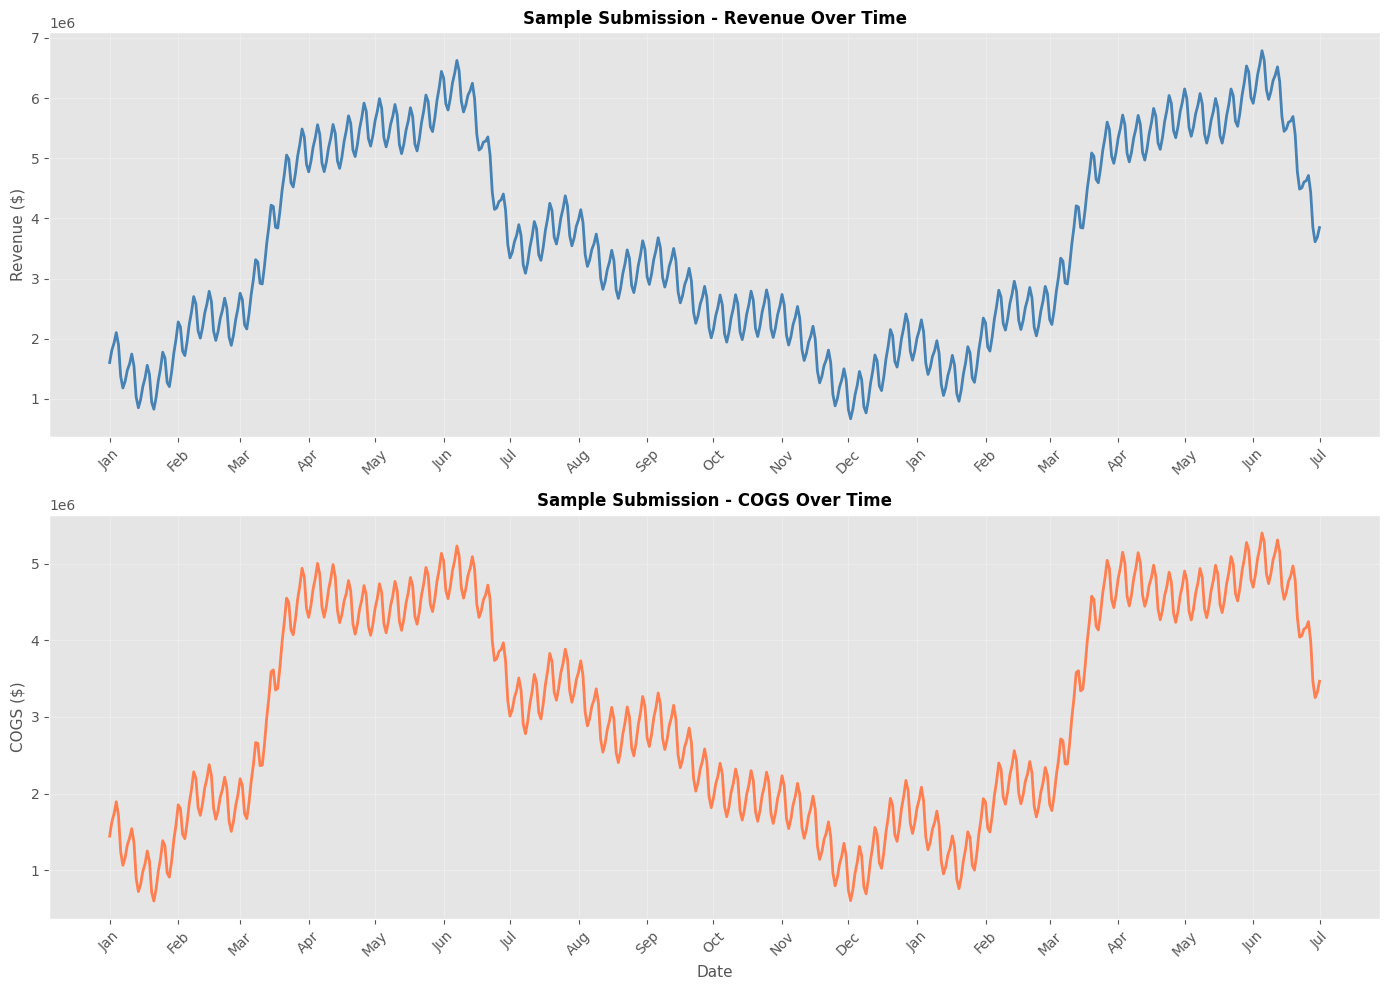

In [48]:
# Load sample submission data
sample_submission = pd.read_csv("../data/submission.csv")
sample_submission['Date'] = pd.to_datetime(sample_submission['Date'])

# Create the graph
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Revenue
axes[0].plot(sample_submission['Date'], sample_submission['Revenue'], linewidth=2, color='steelblue')
axes[0].set_title('Sample Submission - Revenue Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0].tick_params(axis='x', rotation=45)

# COGS
axes[1].plot(sample_submission['Date'], sample_submission['COGS'], linewidth=2, color='coral')
axes[1].set_title('Sample Submission - COGS Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('COGS ($)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()